In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as transforms

# Configuration stricte du backend Keras pour matcher votre environnement
os.environ["KERAS_BACKEND"] = "torch"
import keras

# Métriques d'évaluation
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer

# Importation de vos pipelines existantes
from processing import TextProcessingPipeline, ImageProcessingPipeline

print("Backend Keras configuré sur :", keras.backend.backend())
print("GPU disponible pour PyTorch :", torch.cuda.is_available())

Backend Keras configuré sur : torch
GPU disponible pour PyTorch : False


In [2]:
# 1. Reconstitution de la pipeline de texte et du tokenizer
text_pipe = TextProcessingPipeline()
text_pipe.load_pipeline(tokenizer_path="../tokenizer.pkl", metadata_path="../text_meta.pkl")
tokenizer = text_pipe.tokenizer
max_length = text_pipe.max_length

# 2. Chargement du modèle de fusion Keras (.keras)
model_path = "../flickr8k_caption_generator_resnet.keras"
print(f"Chargement du modèle depuis {model_path}...")
model = keras.models.load_model(model_path)
print("Modèle chargé avec succès.")

Chargement du modèle depuis ../flickr8k_caption_generator_resnet.keras...
Modèle chargé avec succès.


In [3]:
def generate_caption(model, tokenizer, image_feature, max_length, text_pipe):
    """
    Génère une légende pour une image donnée à partir de son vecteur de caractéristiques.
    """
    # Initialisation de la séquence avec le token de départ
    in_text = text_pipe.start_token
    
    for _ in range(max_length):
        # Encodage textuel de la séquence actuelle
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = keras.utils.pad_sequences([sequence], maxlen=max_length)
        
        # Prédiction du mot suivant
        # Le modèle attend [features_image, sequence_texte]
        yhat = model.predict([np.array([image_feature]), np.array(sequence)], verbose=0)
        
        # Récupération de l'index du mot ayant la probabilité maximale
        yhat_idx = np.argmax(yhat)
        
        # Association de l'index au mot correspondant
        word = None
        for w, index in tokenizer.word_index.items():
            if index == yhat_idx:
                word = w
                break
                
        # Si le mot n'est pas trouvé, on arrête
        if word is None:
            break
            
        # Ajout du mot à la séquence d'entrée
        in_text += ' ' + word
        
        # Si on atteint le token de fin, on arrête la génération
        if word == text_pipe.end_token:
            break
            
    # Nettoyage de la chaîne finale pour l'affichage (retrait des tokens de contrôle)
    final_caption = in_text.replace(text_pipe.start_token, '').replace(text_pipe.end_token, '').strip()
    return final_caption

In [4]:
def load_image_ids(filename):
    """
    Charge la liste des identifiants d'images à partir d'un fichier de split officiel.
    """
    with open(filename, 'r', encoding='utf-8') as file:
        doc = file.read()
    
    ids = list()
    for line in doc.split('\n'):
        if len(line) < 1:
            continue
        # Récupération de l'identifiant sans l'extension .jpg
        image_id = line.split('.')[0]
        ids.append(image_id)
    return set(ids)

In [5]:
# Chemin vers le fichier contenant les images de test officielles
TEST_IMAGES_FILE_PATH = "../data/Flickr_8k.testImages.txt" 

# Chargement des données globales
TOKEN_FILE_PATH = "../data/Flickr8k.token.txt"
FEATURES_PICKLE = "../data/features_resnet50.pkl"

img_pipe = ImageProcessingPipeline()
image_features = img_pipe.load_features(FEATURES_PICKLE)
raw_desc = text_pipe.load_raw_descriptions(TOKEN_FILE_PATH)
cleaned_desc = text_pipe.clean_descriptions(raw_desc)

# Chargement des IDs de test officiels et filtrage
test_ids_set = load_image_ids(TEST_IMAGES_FILE_PATH)
available_test_ids = [img_id for img_id in cleaned_desc.keys() if img_id in test_ids_set]

# Sélection d'un échantillon de 50 images de test (jamais vues à l'entraînement)
import random
random.seed(42)  # Pour la reproductibilité des résultats
eval_ids = random.sample(available_test_ids, min(50, len(available_test_ids)))

actual, predicted = list(), list()
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
rouge1_scores, rougeL_scores = [], []

print(f"Calcul des scores sur un échantillon de {len(eval_ids)} images de test...")

for img_id in eval_ids:
    if img_id not in image_features:
        continue
        
    # 1. Génération de la légende par le modèle (Greedy Search)
    feat = image_features[img_id]
    y_pred = generate_caption(model, tokenizer, feat, max_length, text_pipe)
    predicted.append(y_pred.split())
    
    # 2. Récupération des 5 vraies légendes humaines (sans les tokens de contrôle)
    references = []
    for desc in cleaned_desc[img_id]:
        clean_ref = desc.replace(text_pipe.start_token, '').replace(text_pipe.end_token, '').strip()
        references.append(clean_ref.split())
        
        # Calcul du score ROUGE par rapport à chaque référence
        score_r = scorer.score(clean_ref, y_pred)
        rouge1_scores.append(score_r['rouge1'].fmeasure)
        rougeL_scores.append(score_r['rougeL'].fmeasure)
        
    actual.append(references)

# --- Calcul des différents scores BLEU ---
# weights détermine l'importance accordée à chaque n-gramme
bleu1 = corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0))
bleu2 = corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0))
bleu3 = corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0))
bleu4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))

# --- Affichage des résultats ---
print("\n" + "="*40)
print("         RÉSULTATS DES MÉTRIQUES        ")
print("="*40)
print(f"BLEU-1 (Unigrammes)  : {bleu1:.4f}  <- Fidélité du vocabulaire")
print(f"BLEU-2 (Bigrammes)   : {bleu2:.4f}  <- Cohérence locale (paires)")
print(f"BLEU-3 (Trigrammes)  : {bleu3:.4f}  <- Groupes de 3 mots")
print(f"BLEU-4 (4-grammes)   : {bleu4:.4f}  <- Fluidité syntaxique globale")
print("-"*40)
print(f"ROUGE-1 (F-measure)  : {np.mean(rouge1_scores):.4f}")
print(f"ROUGE-L (F-measure)  : {np.mean(rougeL_scores):.4f}")
print("="*40)

Calcul des scores sur un échantillon de 50 images de test...

         RÉSULTATS DES MÉTRIQUES        
BLEU-1 (Unigrammes)  : 0.5025  <- Fidélité du vocabulaire
BLEU-2 (Bigrammes)   : 0.3402  <- Cohérence locale (paires)
BLEU-3 (Trigrammes)  : 0.2176  <- Groupes de 3 mots
BLEU-4 (4-grammes)   : 0.1399  <- Fluidité syntaxique globale
----------------------------------------
ROUGE-1 (F-measure)  : 0.2811
ROUGE-L (F-measure)  : 0.2637


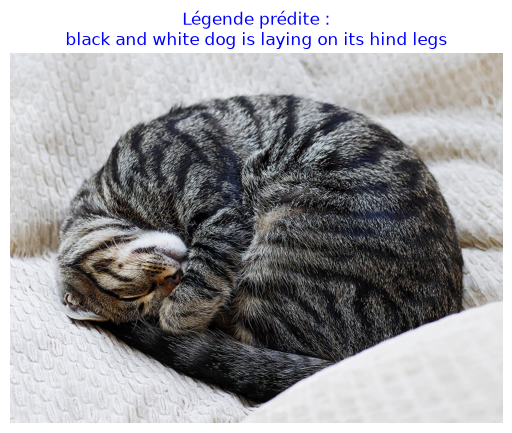

In [6]:
def pipeline_prediction_nouvelle_image(image_path):
    # 1. Configuration du modèle d'extraction (ResNet50 PyTorch)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    resnet50 = models.resnet50(weights=weights)
    resnet50.fc = torch.nn.Identity()
    resnet50 = resnet50.to(device)
    resnet50.eval()
    
    # Transformation standardisée identique à l'entraînement
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 2. Chargement et prétraitement de l'image cible
    img_pil = Image.open(image_path).convert('RGB')
    tensor_img = preprocess(img_pil).unsqueeze(0).to(device)
    
    # 3. Extraction du vecteur de caractéristiques (shape: 2048)
    with torch.no_grad():
        feature_vector = resnet50(tensor_img).cpu().numpy().flatten()
        
    # 4. Génération du texte
    legende = generate_caption(model, tokenizer, feature_vector, max_length, text_pipe)
    
    # 5. Affichage du résultat graphique
    plt.imshow(img_pil)
    plt.title(f"Légende prédite :\n{legende}", fontsize=12, color='blue')
    plt.axis('off')
    plt.show()

# --- EXÉCUTION DU TEST ---
# Remplacez par le chemin d'une vraie image sur votre machine pour tester
CHEMIN_TEST = "../data/papillon2.jpg" 

if os.path.exists(CHEMIN_TEST):
    pipeline_prediction_nouvelle_image(CHEMIN_TEST)
else:
    print(f"Veuillez spécifier un chemin d'image valide dans la variable 'CHEMIN_TEST'.")